# MG-ACT v2 Training Notebook (AIC Phase 1)

End-to-end pipeline: mounts Drive → builds dataset → trains MG-ACT v2 on L4 → saves best-by-val checkpoint that the policy node will load.

**Run cells top-to-bottom.** Each section is independently re-runnable so you can stop, inspect, and resume.

**Expected dataset layout:** `gdrive/MyDrive/aic_data/<dataset_name>/*.h5` — by default this notebook uses `episodes_v2_balanced_0p5`, the balanced `DataCollectv2` dataset with explicit phase labels and terminal HOLD frames. Each H5 file follows the AIC episode format (`actions/translation`, `actions/quaternion_wxyz`, `actions/stiffness_diag`, `actions/damping_diag`, `observations/images/{left,center,right}`, `observations/{joint_position,joint_velocity,joint_effort,wrench}`) and may also include `actions/phase_id` / `actions/phase_name`.

**Recommended first run:** fine-tune from `mg_act_v2_best.pt` on `episodes_v2_balanced_0p5` with `cam_size=(224,224)`. The notebook now supports `finetune_v2`, `resume`, and `scratch_v2` presets plus env-var overrides for dataset name, camera size, epochs, and batch size.

**Outputs:** Run-specific checkpoints are written to `gdrive/MyDrive/aic_data/checkpoints/`, for example `mg_act_episodes_v2_balanced_0p5_224x224_best.pt` and `_last.pt`.

## 0. Environment & Drive mount

Verifies the L4 is visible, installs only what's missing, mounts Google Drive.

In [1]:
import subprocess, sys

def pip_install(pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# Colab usually has torch + torchvision preinstalled. h5py and einops are typically there too.
# Install only what might be missing.
pip_install(['h5py>=3.8', 'einops>=0.7', 'tqdm', 'matplotlib'])

import torch
print(f'torch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    raise RuntimeError('No GPU detected. Switch runtime to T4/L4/A100 via Runtime > Change runtime type.')

torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4
VRAM: 23.7 GB


In [2]:
# Mount Google Drive
from google.colab import drive
import os
import shutil
import subprocess

def mount_drive():
    if not os.path.exists('/content/gdrive/MyDrive'):
        print("Mounting Google Drive...")
        drive.mount('/content/gdrive', force_remount=True)
    else:
        print("Drive already mounted.")

mount_drive()

# 1. Define Paths
DRIVE_DATA_ROOT = '/content/gdrive/MyDrive/aic_data'
DATASET_NAME = os.environ.get('AIC_DATASET_NAME', 'episodes_v2_balanced_0p5')
DRIVE_EPISODES_DIR = os.path.join(DRIVE_DATA_ROOT, DATASET_NAME)
CKPT_DIR = os.path.join(DRIVE_DATA_ROOT, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

# 2. Local Fast Storage Setup
LOCAL_DATA_DIR = '/content/data'
EPISODES_DIR = os.path.join(LOCAL_DATA_DIR, DATASET_NAME)

if not os.path.exists(EPISODES_DIR):
    os.makedirs(EPISODES_DIR, exist_ok=True)

print(f'Dataset name: {DATASET_NAME}')
print(f'Syncing dataset to local storage (using rsync for robustness)...')
print(f'  from: {DRIVE_EPISODES_DIR}')
print(f'  to:   {EPISODES_DIR}')
# rsync is better than cp for resuming after the 'Transport endpoint' errors you saw
# --ignore-existing speeds up subsequent runs if some files already copied
try:
    subprocess.run([
        "rsync", "-ah", "--progress", "--ignore-existing",
        DRIVE_EPISODES_DIR + "/", EPISODES_DIR + "/"
    ], check=True)
    print('Sync complete.')
except subprocess.CalledProcessError as e:
    print(f"Error during sync: {e}. If 'Transport endpoint' error persists, try Runtime > Disconnect and delete runtime.")

# 3. Verify Local Files
assert os.path.isdir(EPISODES_DIR), f'Expected {EPISODES_DIR} to exist.'
h5_files = sorted([f for f in os.listdir(EPISODES_DIR) if f.endswith('.h5')])
print(f'Found {len(h5_files)} H5 episodes in local storage: {EPISODES_DIR}')
if len(h5_files) > 0:
    print(f'First few: {h5_files[:3]}')

Mounting Google Drive...
Mounted at /content/gdrive
Syncing dataset to local storage (using rsync for robustness)...
Sync complete.
Found 502 H5 episodes in local storage: /content/data/episodes
First few: ['episode_1778099657695_59b6c52d.h5', 'episode_1778099796679_98144b14.h5', 'episode_1778099939467_d5ee0a11.h5']


## 1. Sanity-inspect one episode

Confirms the action layout matches the 19-D variable-impedance vector and that all expected groups are present. `DataCollectv2` may also add `collector_version`, `hold_seconds`, `actions/phase_id`, and `actions/phase_name`. If this cell errors, **stop** — there's a dataset format mismatch.

In [3]:
import h5py, numpy as np

sample_path = os.path.join(EPISODES_DIR, h5_files[0])
with h5py.File(sample_path, 'r') as f:
    print('=== File-level attrs ===')
    for k, v in f.attrs.items():
        print(f'  {k} = {v}')
    print()
    print('=== Datasets ===')
    def show(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f'  {name}  shape={obj.shape}  dtype={obj.dtype}')
    f.visititems(show)

    # Spot-check action ranges so we can normalize sensibly
    print()
    print('=== Action ranges (first episode) ===')
    for k in ['actions/translation', 'actions/quaternion_wxyz', 'actions/stiffness_diag', 'actions/damping_diag']:
        a = f[k][()]
        print(f'  {k:35s}  min={a.min():+.3f}  max={a.max():+.3f}  mean={a.mean():+.3f}')

=== File-level attrs ===
  action_layout = translation[3] | quaternion_wxyz[4] | stiffness_diag[6] | damping_diag[6]
  cable_name = cable_0
  control_hz = 16.04699043236042
  duration_s = 33.028
  image_encoding = rgb8
  image_scale = 0.25
  joint_names = [b'shoulder_pan_joint' b'shoulder_lift_joint' b'elbow_joint'
 b'wrist_1_joint' b'wrist_2_joint' b'wrist_3_joint' b'gripper']
  num_steps = 530
  plug_name = sfp_tip
  port_name = sfp_port_0
  success = True
  target_module_name = nic_card_mount_0

=== Datasets ===
  actions/action_19d  shape=(530, 19)  dtype=float32
  actions/damping_diag  shape=(530, 6)  dtype=float32
  actions/quaternion_wxyz  shape=(530, 4)  dtype=float32
  actions/stiffness_diag  shape=(530, 6)  dtype=float32
  actions/translation  shape=(530, 3)  dtype=float32
  actions/z_offset  shape=(530,)  dtype=float32
  observations/images/center  shape=(530, 256, 288, 3)  dtype=uint8
  observations/images/left  shape=(530, 256, 288, 3)  dtype=uint8
  observations/images/ri

In [4]:
# Verify all episodes have the expected layout. Includes a safety timeout to prevent hanging on corrupted files.
from tqdm import tqdm
import concurrent.futures
import os
import h5py

REQUIRED = [
    'actions/translation', 'actions/quaternion_wxyz',
    'actions/stiffness_diag', 'actions/damping_diag',
    'observations/images/left', 'observations/images/center', 'observations/images/right',
    'observations/joint_position', 'observations/joint_velocity', 'observations/joint_effort',
    'observations/wrench',
]

def check_single_file(path):
    # Disable HDF5 file locking to prevent hangs on some filesystems
    os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
    with h5py.File(path, 'r') as f:
        for k in REQUIRED:
            if k not in f:
                return False, f'missing {k}'
        success = bool(f.attrs.get('success', True))
        n_steps = f['actions/translation'].shape[0]
        if not success or n_steps < 30:
            return False, f'success={success}, n_steps={n_steps}'
    return True, ""

valid_files = []
skipped = []

# Use a ProcessPoolExecutor to handle the check with a strict timeout
with concurrent.futures.ProcessPoolExecutor(max_workers=4) as executor:
    future_to_file = {executor.submit(check_single_file, os.path.join(EPISODES_DIR, f)): f for f in h5_files}

    for future in tqdm(concurrent.futures.as_completed(future_to_file, timeout=300), total=len(h5_files), desc='Validating episodes'):
        fname = future_to_file[future]
        try:
            # If a single file takes more than 5 seconds to open/read attrs, it's likely stuck/corrupt
            is_valid, reason = future.result(timeout=5)
            if is_valid:
                valid_files.append(fname)
            else:
                skipped.append((fname, reason))
        except concurrent.futures.TimeoutError:
            skipped.append((fname, 'Timed out during read (likely corrupt)'))
        except Exception as e:
            skipped.append((fname, str(e)))

valid_files.sort()
print(f'\nValid: {len(valid_files)} / {len(h5_files)}')
if skipped:
    print(f'Skipped {len(skipped)} (showing first 5):')
    for f, reason in skipped[:5]:
        print(f'  {f}: {reason}')

Validating episodes: 100%|██████████| 502/502 [00:00<00:00, 571.23it/s]


Valid: 502 / 502


## 2. Train/val split

Holds out 10% of episodes for validation. Fixed seed so the split is stable across re-runs.

In [5]:
import random
import h5py

def file_task_key(path):
    with h5py.File(path, 'r') as f:
        def _get(k):
            v = f.attrs.get(k, '')
            return v.decode() if isinstance(v, bytes) else str(v)
        return (
            _get('target_module_name'),
            _get('port_name'),
            _get('plug_name'),
        )

VAL_FRAC = 0.10
SEED = 42

rng = random.Random(SEED)
groups = {}
for fname in valid_files:
    key = file_task_key(os.path.join(EPISODES_DIR, fname))
    groups.setdefault(key, []).append(fname)

train_files, val_files = [], []
print('Stratified split by task variant:')
for key in sorted(groups):
    files = list(groups[key])
    rng.shuffle(files)
    n_val_k = max(1, int(round(len(files) * VAL_FRAC))) if len(files) > 1 else 0
    val_files.extend(files[:n_val_k])
    train_files.extend(files[n_val_k:])
    print(f'  {key}: total={len(files)}  train={len(files) - n_val_k}  val={n_val_k}')

rng.shuffle(train_files)
rng.shuffle(val_files)
print(f'\nTrain: {len(train_files)}  Val: {len(val_files)}')

Train: 452  Val: 50


## 3. Model code

MG-ACT v2 architecture. Lifted from the skeleton we built earlier — 6D rotation helpers, modality tokenizers, bidirectional cross-attention, proprio-conditioned gate, CVAE encoder, ACT decoder, aux heads. Reproduced inline here so the notebook is self-contained.

In [6]:
import torch
import math
import re
from dataclasses import dataclass
from typing import Optional
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

# ---------- 6D rotation helpers (Zhou et al. 2019) ----------

def rot6d_to_matrix(d6: Tensor) -> Tensor:
    a1, a2 = d6[..., :3], d6[..., 3:]
    b1 = F.normalize(a1, dim=-1)
    b2 = a2 - (b1 * a2).sum(dim=-1, keepdim=True) * b1
    b2 = F.normalize(b2, dim=-1)
    b3 = torch.cross(b1, b2, dim=-1)
    return torch.stack([b1, b2, b3], dim=-2)

def matrix_to_quat_wxyz(R: Tensor) -> Tensor:
    m = R
    t = m[..., 0, 0] + m[..., 1, 1] + m[..., 2, 2]
    eps = 1e-8
    cond1 = t > 0
    s1 = torch.sqrt(t.clamp(min=eps) + 1.0) * 2.0
    w1 = 0.25 * s1; x1 = (m[..., 2, 1] - m[..., 1, 2]) / s1
    y1 = (m[..., 0, 2] - m[..., 2, 0]) / s1; z1 = (m[..., 1, 0] - m[..., 0, 1]) / s1
    cond2 = (m[..., 0, 0] > m[..., 1, 1]) & (m[..., 0, 0] > m[..., 2, 2])
    s2 = torch.sqrt((1.0 + m[..., 0, 0] - m[..., 1, 1] - m[..., 2, 2]).clamp(min=eps)) * 2.0
    w2 = (m[..., 2, 1] - m[..., 1, 2]) / s2; x2 = 0.25 * s2
    y2 = (m[..., 0, 1] + m[..., 1, 0]) / s2; z2 = (m[..., 0, 2] + m[..., 2, 0]) / s2
    cond3 = m[..., 1, 1] > m[..., 2, 2]
    s3 = torch.sqrt((1.0 + m[..., 1, 1] - m[..., 0, 0] - m[..., 2, 2]).clamp(min=eps)) * 2.0
    w3 = (m[..., 0, 2] - m[..., 2, 0]) / s3; x3 = (m[..., 0, 1] + m[..., 1, 0]) / s3
    y3 = 0.25 * s3; z3 = (m[..., 1, 2] + m[..., 2, 1]) / s3
    s4 = torch.sqrt((1.0 + m[..., 2, 2] - m[..., 0, 0] - m[..., 1, 1]).clamp(min=eps)) * 2.0
    w4 = (m[..., 1, 0] - m[..., 0, 1]) / s4; x4 = (m[..., 0, 2] + m[..., 2, 0]) / s4
    y4 = (m[..., 1, 2] + m[..., 2, 1]) / s4; z4 = 0.25 * s4
    w = torch.where(cond1, w1, torch.where(cond2, w2, torch.where(cond3, w3, w4)))
    x = torch.where(cond1, x1, torch.where(cond2, x2, torch.where(cond3, x3, x4)))
    y = torch.where(cond1, y1, torch.where(cond2, y2, torch.where(cond3, y3, y4)))
    z = torch.where(cond1, z1, torch.where(cond2, z2, torch.where(cond3, z3, z4)))
    return F.normalize(torch.stack([w, x, y, z], dim=-1), dim=-1)

def quat_wxyz_to_matrix(q: Tensor) -> Tensor:
    q = F.normalize(q, dim=-1)
    w, x, y, z = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
    R = torch.stack([
        1 - 2*(y*y + z*z), 2*(x*y - z*w),    2*(x*z + y*w),
        2*(x*y + z*w),     1 - 2*(x*x + z*z), 2*(y*z - x*w),
        2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x*x + y*y),
    ], dim=-1)
    return R.reshape(*q.shape[:-1], 3, 3)

def matrix_to_rot6d(R: Tensor) -> Tensor:
    return torch.cat([R[..., 0, :], R[..., 1, :]], dim=-1)

def quat_action_to_network_target(translation, quaternion_wxyz, stiffness_diag, damping_diag):
    R = quat_wxyz_to_matrix(quaternion_wxyz)
    rot6d = matrix_to_rot6d(R)
    log_K = stiffness_diag.clamp(min=1e-3).log()
    log_D = damping_diag.clamp(min=1e-3).log()
    return torch.cat([translation, rot6d, log_K, log_D], dim=-1)

# ---------- v3: Task parsing + vocab ----------

_UNK = "<UNK>"
_CLASS_INT_RE = re.compile(r"^(?P<cls>.+?)_(?P<idx>\d+)$")

def parse_task_string(name: str) -> tuple:
    """('nic_card_mount_0',) -> ('nic_card_mount', 0); ('sc_port_base',) -> ('sc_port_base', 0)."""
    m = _CLASS_INT_RE.match(name)
    if m:
        return m.group("cls"), int(m.group("idx"))
    return name, 0

def build_task_vocab(episode_paths):
    """Scan all episodes, parse target_module_name/port_name/plug_name, build {<UNK>=0, ...}."""
    import h5py
    module_classes, port_classes, plug_classes = {_UNK: 0}, {_UNK: 0}, {_UNK: 0}
    for p in episode_paths:
        with h5py.File(p, "r") as f:
            def _get(k):
                v = f.attrs.get(k, "")
                return v.decode() if isinstance(v, bytes) else str(v)
            m_cls, _ = parse_task_string(_get("target_module_name"))
            p_cls, _ = parse_task_string(_get("port_name"))
            pl_cls, _ = parse_task_string(_get("plug_name"))
        if m_cls and m_cls not in module_classes: module_classes[m_cls] = len(module_classes)
        if p_cls and p_cls not in port_classes: port_classes[p_cls] = len(port_classes)
        if pl_cls and pl_cls not in plug_classes: plug_classes[pl_cls] = len(plug_classes)
    return {"module_class": module_classes, "port_class": port_classes, "plug_class": plug_classes}

def encode_task_dict(task_strings, vocab):
    def _vocab_id(d, k): return d.get(k, d.get(_UNK, 0))
    m_cls, m_idx = parse_task_string(task_strings.get("target_module_name", ""))
    p_cls, p_idx = parse_task_string(task_strings.get("port_name", ""))
    pl_cls, _ = parse_task_string(task_strings.get("plug_name", ""))
    return {
        "module_class": _vocab_id(vocab["module_class"], m_cls),
        "module_idx": float(m_idx),
        "port_class": _vocab_id(vocab["port_class"], p_cls),
        "port_idx": float(p_idx),
        "plug_class": _vocab_id(vocab["plug_class"], pl_cls),
    }

In [7]:
# ---------- Config ----------

@dataclass
class MGActV2Config:
    cam_size: tuple = (224, 224)
    n_cameras: int = 3
    haptic_window: int = 8
    proprio_dim: int = 21
    chunk_size: int = 32
    action_dim: int = 21
    n_phases: int = 4
    d_model: int = 384
    n_heads: int = 6
    enc_layers: int = 4
    dec_layers: int = 6
    dim_ff: int = 1536
    dropout: float = 0.1
    z_dim: int = 32

    # Loss weights — see "Loss-weight rationale" section in v3_notebook_changes.md
    w_action: float = 1.0
    w_kl: float = 0.1     # was 1.0; lowered because task-token now carries the discrete identity that z used to (weakly) encode
    w_recon: float = 0.1
    w_phase: float = 0.05
    w_smooth: float = 0.01
    k_min: float = 10.0; k_max: float = 500.0
    d_min: float = 5.0;  d_max: float = 80.0
    # ---- Task conditioning (v3) ----
    task_module_classes: int = 8     # >= len(vocab) including <UNK>
    task_port_classes: int = 8
    task_plug_classes: int = 8
    task_max_idx: int = 8
    task_embed_dim: int = 96
    use_task_conditioning: bool = True

In [8]:
# ---------- Tokenizers ----------

class VisionTokenizer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        from torchvision.models import resnet18, ResNet18_Weights
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(*list(backbone.children())[:-2])
        self.proj = nn.Conv2d(512, cfg.d_model, kernel_size=1)
        self.cam_embed = nn.Embedding(cfg.n_cameras, cfg.d_model)

    def _pos_embed(self, h, w, d, device):
        y = torch.arange(h, device=device).float()
        x = torch.arange(w, device=device).float()
        yy, xx = torch.meshgrid(y, x, indexing='ij')
        d_half = d // 2
        div = torch.exp(torch.arange(0, d_half, 2, device=device).float() * (-math.log(10000.0) / d_half))
        pe_x = torch.zeros(h, w, d_half, device=device)
        pe_y = torch.zeros(h, w, d_half, device=device)
        pe_x[..., 0::2] = torch.sin(xx.unsqueeze(-1) * div)
        pe_x[..., 1::2] = torch.cos(xx.unsqueeze(-1) * div)
        pe_y[..., 0::2] = torch.sin(yy.unsqueeze(-1) * div)
        pe_y[..., 1::2] = torch.cos(yy.unsqueeze(-1) * div)
        return torch.cat([pe_y, pe_x], dim=-1).reshape(h * w, d)

    def forward(self, imgs):
        B, C, _, H, W = imgs.shape
        x = imgs.reshape(B * C, 3, H, W)
        feat = self.proj(self.stem(x))
        _, d, h, w = feat.shape
        feat = feat.flatten(2).transpose(1, 2)
        pe = self._pos_embed(h, w, d, imgs.device)
        feat = feat + pe.unsqueeze(0)
        cam_ids = torch.arange(C, device=imgs.device).repeat_interleave(h * w)
        cam_emb = self.cam_embed(cam_ids).unsqueeze(0)
        return feat.reshape(B, C * h * w, d) + cam_emb

class HapticTokenizer(nn.Module):
    def __init__(self, cfg, in_dim=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_dim, 32, 3, padding=1), nn.GELU(),
            nn.Conv1d(32, 64, 3, padding=1), nn.GELU(),
            nn.Conv1d(64, cfg.d_model, 3, padding=1),
        )
        self.pos = nn.Parameter(torch.zeros(1, cfg.haptic_window, cfg.d_model))
        nn.init.trunc_normal_(self.pos, std=0.02)

    def forward(self, w):
        x = self.net(w.transpose(1, 2)).transpose(1, 2)
        return x + self.pos

class ProprioEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(cfg.proprio_dim, cfg.d_model), nn.GELU(), nn.Linear(cfg.d_model, cfg.d_model))
    def forward(self, s): return self.net(s)

# ---------- Cross-modal fusion ----------

class CrossAttnBlock(nn.Module):
    def __init__(self, d, h, ff, p):
        super().__init__()
        self.norm_q = nn.LayerNorm(d); self.norm_kv = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, h, dropout=p, batch_first=True)
        self.norm_ff = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Dropout(p), nn.Linear(ff, d))
    def forward(self, q, kv):
        h, _ = self.attn(self.norm_q(q), self.norm_kv(kv), self.norm_kv(kv))
        q = q + h
        return q + self.ff(self.norm_ff(q))

class BiCrossModalFusion(nn.Module):
    def __init__(self, cfg, n_layers=2):
        super().__init__()
        self.v2h = nn.ModuleList([CrossAttnBlock(cfg.d_model, cfg.n_heads, cfg.dim_ff, cfg.dropout) for _ in range(n_layers)])
        self.h2v = nn.ModuleList([CrossAttnBlock(cfg.d_model, cfg.n_heads, cfg.dim_ff, cfg.dropout) for _ in range(n_layers)])
    def forward(self, vis, hap):
        for v2h, h2v in zip(self.v2h, self.h2v):
            new_vis = h2v(vis, hap); new_hap = v2h(hap, vis)
            vis, hap = new_vis, new_hap
        return vis, hap

# ---------- CVAE encoder ----------

class CVAEEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.action_proj = nn.Linear(cfg.action_dim, cfg.d_model)
        self.proprio_proj = nn.Linear(cfg.d_model, cfg.d_model)
        self.cls = nn.Parameter(torch.zeros(1, 1, cfg.d_model))
        nn.init.trunc_normal_(self.cls, std=0.02)
        self.pos = nn.Parameter(torch.zeros(1, cfg.chunk_size + 2, cfg.d_model))
        nn.init.trunc_normal_(self.pos, std=0.02)
        layer = nn.TransformerEncoderLayer(cfg.d_model, cfg.n_heads, cfg.dim_ff, cfg.dropout, 'gelu', batch_first=True, norm_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=cfg.enc_layers)
        self.to_mu = nn.Linear(cfg.d_model, cfg.z_dim)
        self.to_logvar = nn.Linear(cfg.d_model, cfg.z_dim)
    def forward(self, proprio_emb, action_chunk):
        B = proprio_emb.shape[0]
        a = self.action_proj(action_chunk)
        s = self.proprio_proj(proprio_emb).unsqueeze(1)
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, s, a], dim=1) + self.pos[:, :2 + a.shape[1]]
        h = self.enc(x)
        return self.to_mu(h[:, 0]), self.to_logvar(h[:, 0])

In [9]:
# ---------- Task encoder ----------

class TaskEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        e = cfg.task_embed_dim
        self.module_class_embed = nn.Embedding(cfg.task_module_classes, e)
        self.port_class_embed   = nn.Embedding(cfg.task_port_classes, e)
        self.plug_class_embed   = nn.Embedding(cfg.task_plug_classes, e)
        self.idx_proj = nn.Sequential(nn.Linear(2, e), nn.GELU(), nn.Linear(e, e))
        self.proj = nn.Sequential(
            nn.LayerNorm(4 * e),
            nn.Linear(4 * e, cfg.d_model), nn.GELU(),
            nn.Linear(cfg.d_model, cfg.d_model),
        )

    def forward(self, task):
        m  = self.module_class_embed(task["module_class"])
        p  = self.port_class_embed(task["port_class"])
        pl = self.plug_class_embed(task["plug_class"])
        idx = torch.stack([task["module_idx"], task["port_idx"]], dim=-1).to(m.dtype)
        i = self.idx_proj(idx)
        return self.proj(torch.cat([m, p, pl, i], dim=-1))


# ---------- Main policy ----------

class MGActV2(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.vis_tok = VisionTokenizer(cfg)
        self.hap_tok = HapticTokenizer(cfg)
        self.proprio = ProprioEncoder(cfg)
        self.fusion  = BiCrossModalFusion(cfg, n_layers=2)
        self.gate_mlp = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_model), nn.GELU(),
            nn.Linear(cfg.d_model, cfg.d_model), nn.Sigmoid(),
        )
        self.cvae = CVAEEncoder(cfg)
        self.z_proj = nn.Linear(cfg.z_dim, cfg.d_model)
        self.query = nn.Parameter(torch.zeros(1, cfg.chunk_size, cfg.d_model))
        nn.init.trunc_normal_(self.query, std=0.02)
        dec_layer = nn.TransformerDecoderLayer(cfg.d_model, cfg.n_heads, cfg.dim_ff, cfg.dropout, "gelu", batch_first=True)
        self.dec = nn.TransformerDecoder(dec_layer, num_layers=cfg.dec_layers)
        self.head_action = nn.Linear(cfg.d_model, cfg.action_dim)
        self.aux_pool_proj = nn.Linear(cfg.d_model, cfg.d_model)
        self.head_recon = nn.Linear(cfg.d_model, cfg.haptic_window * 6)
        self.head_phase = nn.Linear(cfg.d_model, cfg.n_phases)
        self.task_enc = TaskEncoder(cfg)

    def encode_observation(self, images, wrench_window, proprio, task=None, vis_mask=None):
        vis = self.vis_tok(images)
        hap = self.hap_tok(wrench_window)
        s = self.proprio(proprio)
        if vis_mask is not None:
            vis = vis * vis_mask.float().view(-1, 1, 1)
        vis, hap = self.fusion(vis, hap)
        g = self.gate_mlp(s).unsqueeze(1)
        vis = vis * (1.0 - g)
        hap = hap * g
        if self.cfg.use_task_conditioning and task is not None:
            task_tok = self.task_enc(task).unsqueeze(1)  # (B, 1, d)
            return torch.cat([vis, hap, task_tok], dim=1), s
        return torch.cat([vis, hap], dim=1), s

    def decode_actions(self, fused, s, z):
        B = fused.shape[0]
        z_emb = self.z_proj(z).unsqueeze(1)
        memory = torch.cat([fused, s.unsqueeze(1), z_emb], dim=1)
        return self.head_action(self.dec(self.query.expand(B, -1, -1), memory))

    def aux_predict(self, fused):
        pooled = self.aux_pool_proj(fused.mean(dim=1))
        return self.head_recon(pooled).view(-1, self.cfg.haptic_window, 6), self.head_phase(pooled)

    def training_forward(self, images, wrench_window, proprio, action_chunk, phase_label,
                         task=None, vis_mask=None):
        cfg = self.cfg
        fused, s = self.encode_observation(images, wrench_window, proprio, task=task, vis_mask=vis_mask)
        mu, logvar = self.cvae(s, action_chunk)
        std = (0.5 * logvar).exp()
        z = mu + std * torch.randn_like(std)
        pred = self.decode_actions(fused, s, z)
        wrench_recon, phase_logits = self.aux_predict(fused)
        L_action = F.l1_loss(pred, action_chunk)
        L_kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean()
        L_recon = F.mse_loss(wrench_recon, wrench_window)
        L_phase = F.cross_entropy(phase_logits, phase_label)
        K = pred[..., 9:15]; D = pred[..., 15:21]
        L_smooth = (K[:, 1:] - K[:, :-1]).pow(2).mean() + (D[:, 1:] - D[:, :-1]).pow(2).mean()
        L = (cfg.w_action*L_action + cfg.w_kl*L_kl + cfg.w_recon*L_recon
             + cfg.w_phase*L_phase + cfg.w_smooth*L_smooth)
        return {'loss': L, 'L_action': L_action.detach(), 'L_kl': L_kl.detach(),
                'L_recon': L_recon.detach(), 'L_phase': L_phase.detach(),
                'L_smooth': L_smooth.detach()}

    @torch.inference_mode()
    def predict(self, images, wrench_window, proprio, task=None):
        fused, s = self.encode_observation(images, wrench_window, proprio, task=task)
        z = torch.zeros(fused.shape[0], self.cfg.z_dim, device=fused.device, dtype=fused.dtype)
        return self.decode_actions(fused, s, z)

## 4. Dataset

Each `__getitem__` returns one (observation, action_chunk) sample. Multiple samples per episode (we slide a window through each trajectory).

**Important design choices:**
- We open H5 files lazily per-worker with persistent file handles. Opening on every read is ~10x slower.
- Images are decoded → resized → normalized in the worker. Keeps the GPU fed.
- Actions are converted from 19-D (translation+quat+stiffness+damping) to the 21-D network target (with 6D rotation, log-stiffness, log-damping) **once at load time**.
- Phase labels prefer stored `actions/phase_id` from `DataCollectv2`; legacy episodes fall back to weak derivation from wrench magnitude + trajectory progress.
- Contact-conditioned modality dropout: when `‖F_xyz‖ > 5 N`, randomly mask vision with p=0.5. Plus a flat p=0.1 random vision dropout regardless.

In [10]:
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import numpy as np

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CONTACT_THRESHOLD = 5.0
VIS_DROPOUT_CONTACT = 0.5
VIS_DROPOUT_ALWAYS = 0.1
CROP_PAD = 16

def derive_phase_label_legacy(wrench, step_idx, n_steps):
    f_mag = float(np.linalg.norm(wrench[:3]))
    progress = step_idx / max(1, n_steps - 1)
    if progress > 0.9 and f_mag > CONTACT_THRESHOLD: return 3
    if f_mag > CONTACT_THRESHOLD: return 2
    if progress > 0.5: return 1
    return 0

def load_phase_label(f, step_idx, wrench_t, n_steps):
    if 'actions/phase_id' in f:
        return int(f['actions/phase_id'][step_idx])
    return derive_phase_label_legacy(wrench_t, step_idx, n_steps)

def task_variant_key(ids):
    return (
        int(ids['module_class']), int(ids['module_idx']),
        int(ids['port_class']),   int(ids['port_idx']),
        int(ids['plug_class']),
    )

class AICEpisodeDataset(Dataset):
    def __init__(self, episode_paths, task_vocab, chunk_size=32, haptic_window=8,
                 cam_size=(224, 224), augment=True, contact_dropout=True):
        self.paths = episode_paths
        self.task_vocab = task_vocab
        self.chunk_size = chunk_size
        self.haptic_window = haptic_window
        self.cam_size = cam_size
        self.augment = augment
        self.contact_dropout = contact_dropout
        self._h5_cache = {}

        # Pre-compute per-episode task ids (constant across all timesteps in an episode)
        # AND the (episode, step) index list for sampling.
        self.episode_task = []  # parallel to self.paths
        self.episode_variant = []  # for variant-balanced sampling
        self.index = []
        for ep_idx, p in enumerate(episode_paths):
            with h5py.File(p, 'r') as f:
                n = f['actions/translation'].shape[0]
                def _get(k):
                    v = f.attrs.get(k, "")
                    return v.decode() if isinstance(v, bytes) else str(v)
                strings = {
                    "target_module_name": _get("target_module_name"),
                    "port_name":          _get("port_name"),
                    "plug_name":          _get("plug_name"),
                }
            ids = encode_task_dict(strings, task_vocab)
            self.episode_task.append(ids)
            self.episode_variant.append(task_variant_key(ids))
            min_t = haptic_window - 1
            max_t = n - chunk_size
            if max_t >= min_t:
                for t in range(min_t, max_t + 1):
                    self.index.append((ep_idx, t))

        if augment:
            self.img_tf = T.Compose([
                T.ToPILImage(),
                T.Resize((cam_size[0] + CROP_PAD, cam_size[1] + CROP_PAD), antialias=True),
                T.RandomCrop(cam_size),
                T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
                T.ToTensor(),
                T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])
        else:
            self.img_tf = T.Compose([
                T.ToPILImage(), T.Resize(cam_size, antialias=True), T.ToTensor(),
                T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])

    def __len__(self): return len(self.index)

    def _get_handle(self, path):
        if path not in self._h5_cache:
            self._h5_cache[path] = h5py.File(path, 'r')
        return self._h5_cache[path]

    def __getitem__(self, idx):
        ep_idx, t = self.index[idx]
        f = self._get_handle(self.paths[ep_idx])
        n_steps = f['actions/translation'].shape[0]

        imgs = []
        for cam in ('left', 'center', 'right'):
            raw = f[f'observations/images/{cam}'][t]
            imgs.append(self.img_tf(raw))
        images = torch.stack(imgs, dim=0)

        w_start = t - self.haptic_window + 1
        wrench_np = f['observations/wrench'][w_start:t+1]
        wrench = torch.from_numpy(wrench_np).float()
        if self.augment:
            wrench = wrench + torch.randn_like(wrench) * 0.3

        jp = f['observations/joint_position'][t]
        jv = f['observations/joint_velocity'][t]
        je = f['observations/joint_effort'][t]
        proprio = torch.from_numpy(np.concatenate([jp, jv, je])).float()

        chunk_t = slice(t, t + self.chunk_size)
        trans = torch.from_numpy(f['actions/translation'][chunk_t]).float()
        quat  = torch.from_numpy(f['actions/quaternion_wxyz'][chunk_t]).float()
        K     = torch.from_numpy(f['actions/stiffness_diag'][chunk_t]).float()
        D     = torch.from_numpy(f['actions/damping_diag'][chunk_t]).float()
        action_chunk = quat_action_to_network_target(trans, quat, K, D)

        wrench_t = wrench_np[-1]
        phase = load_phase_label(f, t, wrench_t, n_steps)

        f_mag = float(np.linalg.norm(wrench_t[:3]))
        in_contact = f_mag > CONTACT_THRESHOLD
        if self.contact_dropout:
            p_drop = VIS_DROPOUT_CONTACT if in_contact else VIS_DROPOUT_ALWAYS
            vis_mask = torch.tensor(np.random.rand() > p_drop, dtype=torch.bool)
        else:
            vis_mask = torch.tensor(True)

        ids = self.episode_task[ep_idx]
        return {
            'images': images,
            'wrench_window': wrench,
            'proprio': proprio,
            'action_chunk': action_chunk,
            'phase_label': torch.tensor(phase, dtype=torch.long),
            'vis_mask': vis_mask,
            # Task fields (per-step, constant within an episode)
            'task_module_class': torch.tensor(ids["module_class"], dtype=torch.long),
            'task_module_idx':   torch.tensor(ids["module_idx"], dtype=torch.float32),
            'task_port_class':   torch.tensor(ids["port_class"], dtype=torch.long),
            'task_port_idx':     torch.tensor(ids["port_idx"], dtype=torch.float32),
            'task_plug_class':   torch.tensor(ids["plug_class"], dtype=torch.long),
        }


# ---------------- Build vocab + datasets ----------------

train_paths = [os.path.join(EPISODES_DIR, f) for f in train_files]
val_paths   = [os.path.join(EPISODES_DIR, f) for f in val_files]

task_vocab = build_task_vocab(train_paths)  # built ONLY from train; val uses same vocab
print('Task vocab:')
for k, d in task_vocab.items():
    print(f'  {k}: {d}')

TRAIN_CAM_EDGE = int(os.environ.get('AIC_CAM_SIZE', '224'))
TRAIN_CAM_SIZE = (TRAIN_CAM_EDGE, TRAIN_CAM_EDGE)  # Recommended first v2 run; try 320 only after a stable fine-tune.
cfg = MGActV2Config(cam_size=TRAIN_CAM_SIZE)
# Sanity: vocab must fit in cfg's embedding-table sizes
assert len(task_vocab["module_class"]) <= cfg.task_module_classes, "Increase cfg.task_module_classes"
assert len(task_vocab["port_class"])   <= cfg.task_port_classes,   "Increase cfg.task_port_classes"
assert len(task_vocab["plug_class"])   <= cfg.task_plug_classes,   "Increase cfg.task_plug_classes"

train_ds = AICEpisodeDataset(train_paths, task_vocab, chunk_size=cfg.chunk_size,
                             haptic_window=cfg.haptic_window, cam_size=cfg.cam_size,
                             augment=True, contact_dropout=True)
val_ds   = AICEpisodeDataset(val_paths,   task_vocab, chunk_size=cfg.chunk_size,
                             haptic_window=cfg.haptic_window, cam_size=cfg.cam_size,
                             augment=False, contact_dropout=False)

# ---------------- Variant-balanced sampling for train ----------------
# V2 collection is balanced across both NIC cards, both SFP ports, and the
# SC task. Weight by the full task signature so each variant contributes
# similar gradient mass even if trajectory lengths differ slightly.
class_counts = {}
for ep_idx, _ in train_ds.index:
    c = train_ds.episode_variant[ep_idx]
    class_counts[c] = class_counts.get(c, 0) + 1
inv_freq = {c: 1.0 / n for c, n in class_counts.items()}
sample_weights = [inv_freq[train_ds.episode_variant[ep_idx]] for ep_idx, _ in train_ds.index]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
print(f'Variant-balanced sampler — variant counts: {class_counts}')
print(f'Camera size: {cfg.cam_size}')

print(f'Train samples: {len(train_ds)}  Val samples: {len(val_ds)}')
sample = train_ds[0]
print('Sample keys + shapes:')
for k, v in sample.items():
    print(f'  {k}: {v.shape if hasattr(v, "shape") else v}')

Task vocab:
  module_class: {'<UNK>': 0, 'nic_card_mount': 1, 'sc_port': 2}
  port_class: {'<UNK>': 0, 'sfp_port': 1, 'sc_port_base': 2}
  plug_class: {'<UNK>': 0, 'sfp_tip': 1, 'sc_tip': 2}
Class-balanced sampler — class counts: {1: 176400, 2: 45080}
Train samples: 221480  Val samples: 24500
Sample keys + shapes:
  images: torch.Size([3, 3, 224, 224])
  wrench_window: torch.Size([8, 6])
  proprio: torch.Size([21])
  action_chunk: torch.Size([32, 21])
  phase_label: torch.Size([])
  vis_mask: torch.Size([])
  task_module_class: torch.Size([])
  task_module_idx: torch.Size([])
  task_port_class: torch.Size([])
  task_port_idx: torch.Size([])
  task_plug_class: torch.Size([])


In [11]:
# DataLoaders

BATCH_SIZE = int(os.environ.get('AIC_BATCH_SIZE', '24'))
NUM_WORKERS = int(os.environ.get('AIC_NUM_WORKERS', '8'))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
print(f'Train batches/epoch: {len(train_loader)}  Val batches: {len(val_loader)}')
print(f'BATCH_SIZE={BATCH_SIZE}  NUM_WORKERS={NUM_WORKERS}')

# Time one batch end-to-end before training to catch I/O issues early
import time
t0 = time.time()
_batch = next(iter(train_loader))
print(f'First batch loaded in {time.time() - t0:.2f}s')
for k, v in _batch.items():
    print(f'  {k}: {v.shape} {v.dtype}')
del _batch

Train batches/epoch: 9228  Val batches: 1021
First batch loaded in 8.55s
  images: torch.Size([24, 3, 3, 224, 224]) torch.float32
  wrench_window: torch.Size([24, 8, 6]) torch.float32
  proprio: torch.Size([24, 21]) torch.float32
  action_chunk: torch.Size([24, 32, 21]) torch.float32
  phase_label: torch.Size([24]) torch.int64
  vis_mask: torch.Size([24]) torch.bool
  task_module_class: torch.Size([24]) torch.int64
  task_module_idx: torch.Size([24]) torch.float32
  task_port_class: torch.Size([24]) torch.int64
  task_port_idx: torch.Size([24]) torch.float32
  task_plug_class: torch.Size([24]) torch.int64


## 5. Training loop

AdamW, cosine schedule with warmup, bf16 autocast, gradient clipping. Per-step train loss to a running list; per-epoch val pass. Saves run-specific checkpoints to Drive.

**Diagnostics during training:**
- Live plot of train/val total loss
- Per-component train loss breakdown (action, KL, recon, phase, smooth)
- Sample predicted-vs-target action chunks every N epochs

**Recommended default for the new v2 data:** use the `finetune_v2` preset first. It starts from `mg_act_v2_best.pt`, keeps `cam_size=(224, 224)`, and runs a shorter fine-tune. Once that is stable, try a second run at a larger `cam_size`.

In [12]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os

TRAIN_PRESET = os.environ.get('AIC_TRAIN_PRESET', 'finetune_v2')
RUN_NAME = os.environ.get('AIC_RUN_NAME', f'mg_act_{DATASET_NAME}_{cfg.cam_size[0]}x{cfg.cam_size[1]}')

if TRAIN_PRESET == 'finetune_v2':
    INIT_MODE = 'finetune'          # load model weights only
    INIT_CKPT_NAME = 'mg_act_v2_best.pt'
    EPOCHS = 15
    LR_BACKBONE = 5e-6
    LR_HEAD     = 5e-5
elif TRAIN_PRESET == 'resume':
    INIT_MODE = 'resume'            # load model + optimizer + scheduler if present
    INIT_CKPT_NAME = f'{RUN_NAME}_last.pt'
    EPOCHS = 30
    LR_BACKBONE = 1e-5
    LR_HEAD     = 1e-4
elif TRAIN_PRESET == 'scratch_v2':
    INIT_MODE = 'scratch'
    INIT_CKPT_NAME = None
    EPOCHS = 30
    LR_BACKBONE = 1e-5
    LR_HEAD     = 1e-4
else:
    raise ValueError(f'Unknown TRAIN_PRESET: {TRAIN_PRESET}')

EPOCHS = int(os.environ.get('AIC_EPOCHS', EPOCHS))
LR_BACKBONE = float(os.environ.get('AIC_LR_BACKBONE', LR_BACKBONE))
LR_HEAD = float(os.environ.get('AIC_LR_HEAD', LR_HEAD))

WD          = 1e-4
WARMUP_FRAC = 0.05
GRAD_CLIP   = 1.0
VAL_EVERY_EPOCH = 1

# Build model
torch.manual_seed(SEED)
model = MGActV2(cfg).cuda()

# Param groups: ResNet backbone gets lower LR
backbone_params = list(model.vis_tok.stem.parameters())
backbone_ids = {id(p) for p in backbone_params}
head_params = [p for p in model.parameters() if id(p) not in backbone_ids]

optim = AdamW([
    {'params': backbone_params, 'lr': LR_BACKBONE, 'weight_decay': WD},
    {'params': head_params,     'lr': LR_HEAD,     'weight_decay': WD},
])

total_steps = EPOCHS * len(train_loader)
warmup_steps = int(WARMUP_FRAC * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

sched = LambdaLR(optim, lr_lambda)
scaler = None  # bf16 doesn't need GradScaler

def set_scheduler_to_step(step_idx):
    sched.last_epoch = step_idx
    base_lrs = [LR_BACKBONE, LR_HEAD]
    factor = lr_lambda(step_idx)
    for group, base_lr in zip(optim.param_groups, base_lrs):
        group['lr'] = base_lr * factor

# Trackers
history = {
    'train_total': [], 'train_action': [], 'train_kl': [], 'train_recon': [], 'train_phase': [], 'train_smooth': [],
    'val_total': [], 'val_action': [], 'val_epoch': [],
    'lr': [],
}
best_val = float('inf')
start_epoch = 0

best_ckpt_path = os.path.join(CKPT_DIR, f'{RUN_NAME}_best.pt')
last_ckpt_path = os.path.join(CKPT_DIR, f'{RUN_NAME}_last.pt')
init_ckpt_path = os.path.join(CKPT_DIR, INIT_CKPT_NAME) if INIT_CKPT_NAME else None

if INIT_MODE != 'scratch':
    if init_ckpt_path is None or not os.path.exists(init_ckpt_path):
        raise FileNotFoundError(f'Checkpoint not found for INIT_MODE={INIT_MODE}: {init_ckpt_path}')
    print(f'Initializing from {init_ckpt_path} (mode={INIT_MODE})...')
    ckpt = torch.load(init_ckpt_path, map_location='cuda')
    model.load_state_dict(ckpt['model_state'])

    if INIT_MODE == 'resume':
        start_epoch = ckpt.get('epoch', 0)
        if 'history' in ckpt:
            history = ckpt['history']
        if 'val_metrics' in ckpt:
            best_val = ckpt['val_metrics'].get('L_action', float('inf'))

        if 'optim_state' in ckpt:
            optim.load_state_dict(ckpt['optim_state'])
            print('Optimizer state loaded.')
        else:
            print('Warning: Optimizer state not found in checkpoint. Momentum will be reset.')

        if 'sched_state' in ckpt:
            sched.load_state_dict(ckpt['sched_state'])
            print('Scheduler state loaded.')
        else:
            steps_to_catch_up = start_epoch * len(train_loader)
            set_scheduler_to_step(steps_to_catch_up)
            print(f'Scheduler aligned to step {steps_to_catch_up}.')
    else:
        print('Fine-tune mode: optimizer, scheduler, and history reset; model weights loaded only.')

print(f'Total optimizer steps: {total_steps} (warmup: {warmup_steps})')
print(f'TRAIN_PRESET={TRAIN_PRESET}  RUN_NAME={RUN_NAME}  INIT_MODE={INIT_MODE}')
print(f'cam_size={cfg.cam_size}  epochs={EPOCHS}  lr_backbone={LR_BACKBONE:.2e}  lr_head={LR_HEAD:.2e}')
print(f'Starting from epoch {start_epoch}')
print(f'Best checkpoint will be saved to: {best_ckpt_path}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]
/tmp/ipykernel_5432/2767879015.py:96: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(layer, num_layers=cfg.enc_layers)


Resuming from /content/gdrive/MyDrive/aic_data/checkpoints/mg_act_v2_e14.pt...


/tmp/ipykernel_5432/4017057407.py:78: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


Scheduler advanced by 129192 steps.
Total optimizer steps: 276840 (warmup: 13842)
Starting from epoch 14
Best checkpoint will be saved to: /content/gdrive/MyDrive/aic_data/checkpoints/mg_act_v2_best.pt


In [13]:
def to_cuda(batch):
    return {k: v.cuda(non_blocking=True) for k, v in batch.items()}

@torch.inference_mode()
def validate():
    model.eval()
    totals = {'loss': 0.0, 'L_action': 0.0, 'L_kl': 0.0, 'L_recon': 0.0, 'L_phase': 0.0, 'L_smooth': 0.0}
    n = 0
    for batch in val_loader:
        batch = to_cuda(batch)
        task = {
            "module_class": batch["task_module_class"],
            "module_idx":   batch["task_module_idx"],
            "port_class":   batch["task_port_class"],
            "port_idx":     batch["task_port_idx"],
            "plug_class":   batch["task_plug_class"],
        }
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            out = model.training_forward(
                images=batch['images'],
                wrench_window=batch['wrench_window'],
                proprio=batch['proprio'],
                action_chunk=batch['action_chunk'],
                phase_label=batch['phase_label'],
                task=task,
                vis_mask=None,
            )
        bs = batch['images'].shape[0]
        for k in totals:
            totals[k] += float(out[k] if k == 'loss' else out[k]) * bs
        n += bs
    return {k: v / n for k, v in totals.items()}

def plot_progress():
    clear_output(wait=True)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    # Total loss train vs val
    ax = axes[0, 0]
    ax.plot(history['train_total'], label='train', alpha=0.5, linewidth=0.7)
    if history['val_total']:
        # Map val_epoch to step indices (approximate)
        steps_per_epoch = len(train_loader)
        val_x = [e * steps_per_epoch for e in history['val_epoch']]
        ax.plot(val_x, history['val_total'], 'o-', label='val', markersize=5)
    ax.set_xlabel('step'); ax.set_ylabel('loss'); ax.set_title('Total loss')
    ax.legend(); ax.grid(alpha=0.3)

    # Train component losses
    ax = axes[0, 1]
    for key, label in [('train_action', 'L_action'), ('train_kl', 'L_kl'),
                       ('train_recon', 'L_recon'), ('train_phase', 'L_phase'), ('train_smooth', 'L_smooth')]:
        if history[key]:
            ax.plot(history[key], label=label, alpha=0.7, linewidth=0.7)
    ax.set_xlabel('step'); ax.set_ylabel('loss'); ax.set_title('Train: per-component')
    ax.legend(); ax.grid(alpha=0.3); ax.set_yscale('log')

    # Val action loss
    ax = axes[1, 0]
    if history['val_action']:
        ax.plot(history['val_epoch'], history['val_action'], 'o-')
    ax.set_xlabel('epoch'); ax.set_ylabel('L_action (val)')
    ax.set_title(f'Val action L1  (best: {best_val:.4f})')
    ax.grid(alpha=0.3)

    # Learning rate
    ax = axes[1, 1]
    ax.plot(history['lr'])
    ax.set_xlabel('step'); ax.set_ylabel('lr (head group)'); ax.set_title('LR schedule')
    ax.grid(alpha=0.3); ax.set_yscale('log')

    plt.tight_layout(); plt.show()

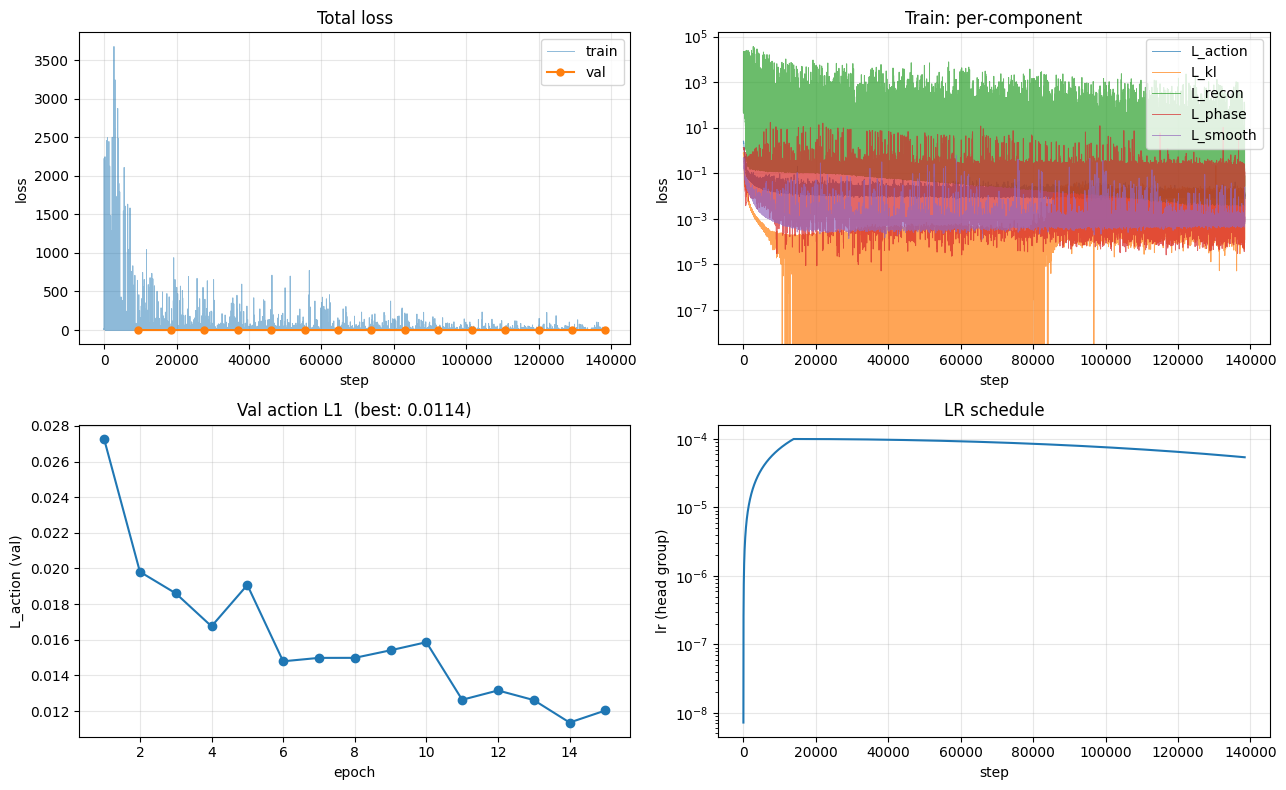

Epoch 15/30  train_loss=0.2814  val_loss=0.0174  val_L_action=0.0120


Epoch 16/30:   0%|          | 0/9228 [00:00<?, ?it/s]

In [ ]:
from tqdm.auto import tqdm

global_step = start_epoch * len(train_loader)

for epoch in range(start_epoch, EPOCHS):
    model.train()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False)
    epoch_running = {'loss': 0.0, 'n': 0}

    for batch in pbar:
        batch = to_cuda(batch)

        # Construct task dict
        task = {
            "module_class": batch["task_module_class"],
            "module_idx":   batch["task_module_idx"],
            "port_class":   batch["task_port_class"],
            "port_idx":     batch["task_port_idx"],
            "plug_class":   batch["task_plug_class"],
        }

        # Updated to the new recommended API
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            out = model.training_forward(
                images=batch['images'],
                wrench_window=batch['wrench_window'],
                proprio=batch['proprio'],
                action_chunk=batch['action_chunk'],
                phase_label=batch['phase_label'],
                task=task,
                vis_mask=batch['vis_mask'],
            )
        loss = out['loss']

        optim.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optim.step()
        sched.step()

        # Log
        history['train_total'].append(float(loss))
        history['train_action'].append(float(out['L_action']))
        history['train_kl'].append(float(out['L_kl']))
        history['train_recon'].append(float(out['L_recon']))
        history['train_phase'].append(float(out['L_phase']))
        history['train_smooth'].append(float(out['L_smooth']))
        history['lr'].append(optim.param_groups[1]['lr'])  # head LR

        epoch_running['loss'] += float(loss); epoch_running['n'] += 1
        pbar.set_postfix(loss=f"{loss.item():.3f}", L_act=f"{float(out['L_action']):.3f}")
        global_step += 1

    # Validation and Checkpointing
    if (epoch + 1) % VAL_EVERY_EPOCH == 0:
        val_metrics = validate()
        history['val_total'].append(val_metrics['loss'])
        history['val_action'].append(val_metrics['L_action'])
        history['val_epoch'].append(epoch + 1)

        is_best = val_metrics['L_action'] < best_val
        if is_best:
            best_val = val_metrics['L_action']

        # Save checkpoint with epoch suffix, including optim and sched states!
        epoch_ckpt_path = os.path.join(CKPT_DIR, f'mg_act_v2_e{epoch + 1}.pt')
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'optim_state': optim.state_dict(),
            'sched_state': sched.state_dict(),
            'cfg': cfg.__dict__,
            'task_vocab': task_vocab,
            'val_metrics': val_metrics,
            'history': history,
        }, epoch_ckpt_path)
        import shutil
        shutil.copy2(epoch_ckpt_path, last_ckpt_path)

        # Also update the 'best' symlink/copy if this is the new best
        if is_best:
             shutil.copy2(epoch_ckpt_path, best_ckpt_path)

        plot_progress()
        train_avg = epoch_running['loss'] / max(1, epoch_running['n'])
        flag = '  ★ NEW BEST' if is_best else ''
        print(f'Epoch {epoch+1}/{EPOCHS}  train_loss={train_avg:.4f}  '
              f'val_loss={val_metrics["loss"]:.4f}  val_L_action={val_metrics["L_action"]:.4f}{flag}')

print(f'\nDone. Best val L_action: {best_val:.4f}\nCheckpoints saved in: {CKPT_DIR}')

## 6. Post-training inspection

Plots predicted vs. ground-truth action chunks on a few val samples. Quick visual check that the network actually learned the task structure rather than just minimizing loss numerically.

In [ ]:
# Reload best checkpoint
ckpt = torch.load(best_ckpt_path, map_location='cuda')
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}, val L_action={ckpt['val_metrics']['L_action']:.4f}")

# Pull a few val samples and predict
n_samples = 4
val_iter = iter(val_loader)
batch = to_cuda(next(val_iter))

with torch.cuda.amp.autocast(dtype=torch.bfloat16):
    pred = model.predict(batch['images'][:n_samples], batch['wrench_window'][:n_samples], batch['proprio'][:n_samples])

pred = pred.float().cpu().numpy()
gt   = batch['action_chunk'][:n_samples].float().cpu().numpy()

fig, axes = plt.subplots(n_samples, 4, figsize=(16, 3 * n_samples))
channel_groups = [
    ('Translation', slice(0, 3)),
    ('Rotation 6D', slice(3, 9)),
    ('log Stiffness', slice(9, 15)),
    ('log Damping', slice(15, 21)),
]
for i in range(n_samples):
    for j, (name, sl) in enumerate(channel_groups):
        ax = axes[i, j] if n_samples > 1 else axes[j]
        for ch in range(sl.start, sl.stop):
            ax.plot(gt[i, :, ch], '--', alpha=0.5, linewidth=0.8)
            ax.plot(pred[i, :, ch], '-', alpha=0.8, linewidth=0.8)
        ax.set_title(f'Sample {i} — {name}' if i == 0 else name, fontsize=9)
        ax.grid(alpha=0.3)
        if i == n_samples - 1:
            ax.set_xlabel('chunk step')
plt.tight_layout(); plt.show()
print('Dashed = ground truth   Solid = predicted')

In [ ]:
# Per-channel MSE on full val set, so you can tell which sub-action regresses well/poorly
@torch.inference_mode()
def per_channel_mse():
    model.eval()
    sums = torch.zeros(cfg.action_dim).cuda()
    n = 0
    for batch in val_loader:
        batch = to_cuda(batch)
        with torch.cuda.amp.autocast(dtype=torch.bfloat16):
            pred = model.predict(batch['images'], batch['wrench_window'], batch['proprio']).float()
        gt = batch['action_chunk'].float()
        sums += ((pred - gt) ** 2).mean(dim=(0, 1))  # over batch and chunk
        n += 1
    return (sums / n).cpu().numpy()

mse = per_channel_mse()
channel_names = (['trans_x', 'trans_y', 'trans_z']
                 + [f'rot6d_{i}' for i in range(6)]
                 + [f'log_K_{i}' for i in range(6)]
                 + [f'log_D_{i}' for i in range(6)])
print(f'{"Channel":<14s} {"MSE":>10s}')
for name, v in zip(channel_names, mse):
    print(f'  {name:<12s} {v:10.5f}')

## 7. Inference smoke test

Mimics what the policy node will do at runtime: take one fake observation, run `predict()`, convert the 21-D output to the 19-D ROS payload (with safety clamps), confirm shapes.

In [ ]:
def network_action_to_ros_payload(pred, cfg):
    """21-D net output -> 19-D AIC layout (translation + quat_wxyz + K + D), with safety clamps."""
    trans = pred[..., 0:3]
    rot6d = pred[..., 3:9]
    log_K = pred[..., 9:15]
    log_D = pred[..., 15:21]
    R = rot6d_to_matrix(rot6d)
    quat = matrix_to_quat_wxyz(R)
    K = log_K.exp().clamp(min=cfg.k_min, max=cfg.k_max)
    D = log_D.exp().clamp(min=cfg.d_min, max=cfg.d_max)
    # Workspace clamp -- TUNE TO YOUR DATASET
    trans = trans.clone()
    trans[..., 0] = trans[..., 0].clamp(min=-0.7, max=0.0)
    trans[..., 1] = trans[..., 1].clamp(min=-0.5, max=0.5)
    trans[..., 2] = trans[..., 2].clamp(min=0.05, max=0.5)
    return {'translation': trans, 'quaternion_wxyz': quat, 'stiffness_diag': K, 'damping_diag': D}

import time

model.eval()
fake_imgs = torch.rand(1, 3, 3, 224, 224).cuda()
fake_wrench = torch.randn(1, 8, 6).cuda()
fake_proprio = torch.randn(1, 21).cuda()

# Warmup
for _ in range(3):
    _ = model.predict(fake_imgs, fake_wrench, fake_proprio)
torch.cuda.synchronize()

# Time 20 inference calls (no autocast at first to be fair)
ts = []
for _ in range(20):
    t0 = time.time()
    with torch.cuda.amp.autocast(dtype=torch.bfloat16):
        pred = model.predict(fake_imgs, fake_wrench, fake_proprio)
    torch.cuda.synchronize()
    ts.append(time.time() - t0)

print(f'Mean inference (bs=1, bf16): {np.mean(ts)*1000:.1f} ms  (max {np.max(ts)*1000:.1f} ms)')
print(f'(Need to run faster than ~50 ms for 20 Hz; ~100 ms for 10 Hz)')

payload = network_action_to_ros_payload(pred.float(), cfg)
print('\nROS payload shapes:')
for k, v in payload.items():
    print(f'  {k}: {v.shape}')

## 8. What to do with the checkpoint

The best checkpoint is at `aic_data/checkpoints/mg_act_v2_best.pt`. To load it inside the AIC policy node (`MGActV2Policy.__init__`):

```python
ckpt = torch.load(local_ckpt_path, map_location='cuda')
cfg = MGActV2Config(**ckpt['cfg'])
self.model = MGActV2(cfg).cuda().eval()
self.model.load_state_dict(ckpt['model_state'])
```

Inside `insert_cable()` at each tick:
1. Pull `Observation` via `get_observation()`.
2. Maintain a wrench ring buffer; build `wrench_window`.
3. Decode the 3 images (sensor_msgs/Image → tensor, normalize with ImageNet mean/std).
4. Build the 21-D proprio vector from joint state.
5. `pred = model.predict(images, wrench_window, proprio)`  →  21-D chunk.
6. Apply temporal ensembling against your buffer of recent predictions.
7. `payload = network_action_to_ros_payload(pred[:, 0:1], cfg)` for the next action.
8. Build `MotionUpdate` and call `move_robot()`.

Don't forget: in `on_activate()`, call `change_target_mode` to put the controller in **Cartesian** mode before the first `move_robot()` call.